# Trust Wallet — Analyse des distributions de gas

Analyse des transactions Trust Wallet (EIP-7702, `0xd2e28229f6f2c235e57de2ebc727025a1d0530fb`) depuis `gas.db`.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['figure.dpi'] = 120

DB_PATH = Path('..') / 'gas.db'

con = sqlite3.connect(DB_PATH)
df = pd.read_sql_query("""
    SELECT
        hash, block,
        max_fee_gwei,
        max_priority_gwei,
        base_fee_gwei,
        fee_factor,
        fee_factor_parent,
        gas_limit,
        estimated_gas,
        gas_limit_factor
    FROM transactions
    WHERE wallet = 'Trust Wallet'
      AND tx_type = 2
      AND max_priority_gwei IS NOT NULL
""", con)
con.close()

print(f"Transactions chargées : {len(df):,}")
print(f"Blocs couverts        : {df.block.min():,} → {df.block.max():,}")
df.describe().round(4)

Transactions chargées : 44,127
Blocs couverts        : 24,000,003 → 24,324,933


,block,max_fee_gwei,max_priority_gwei,base_fee_gwei,fee_factor,fee_factor_parent,gas_limit,estimated_gas,gas_limit_factor
count,4.412700e+04,44127.0000,44127.0000,44127.0000,44127.0000,44127.0000,4.412700e+04,4.376700e+04,43767.0000
mean,2.421670e+07,0.6443,0.5206,0.0635,1.9111,1.9020,1.095721e+05,8.957692e+04,1.1692
std,1.217176e+05,0.8959,0.6197,0.0569,11.7389,11.1048,1.760319e+05,1.365303e+05,0.2755
min,2.400000e+07,0.0261,0.0000,0.0196,0.0000,0.0000,2.100000e+04,2.100000e+04,0.4438
25%,2.411764e+07,0.1137,0.0000,0.0350,1.1893,1.2000,4.878100e+04,4.554000e+04,1.0000
50%,2.430273e+07,0.8931,0.2000,0.0435,1.4238,1.3750,6.974900e+04,6.307800e+04,1.0000
75%,2.431086e+07,1.0525,1.0000,0.0646,2.5066,2.5000,9.606400e+04,8.726000e+04,1.5000
max,2.432493e+07,60.0000,35.0000,1.0551,1844.1263,1678.8669,5.634624e+06,5.294179e+06,9.1849


## 1. Top 10 — Priority fee (`maxPriorityFeePerGas`)

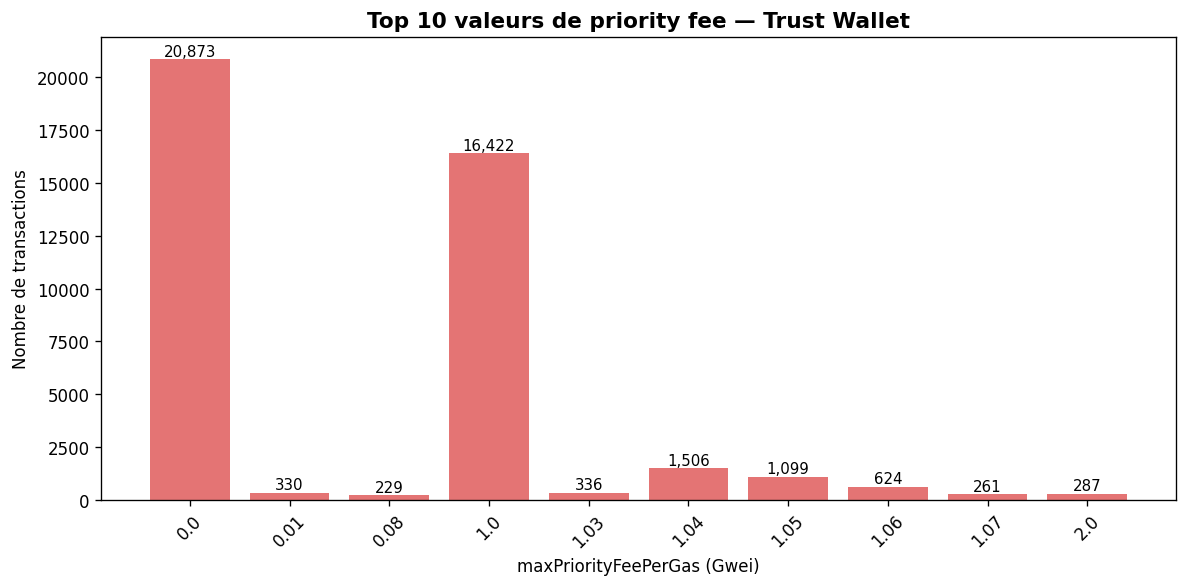


Top 10 valeurs de priority fee (arrondi à 2dp) :
max_priority_gwei
0.00    20873
1.00    16422
1.04     1506
1.05     1099
1.06      624
1.03      336
0.01      330
2.00      287
1.07      261
0.08      229


In [2]:
prio = df['max_priority_gwei'].dropna()

top_prio = prio.round(2).value_counts().head(10).sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(top_prio.index.astype(str), top_prio.values, color='#E05C5C', alpha=0.85)
ax.set_title('Top 10 valeurs de priority fee — Trust Wallet', fontsize=13, fontweight='bold')
ax.set_xlabel('maxPriorityFeePerGas (Gwei)')
ax.set_ylabel('Nombre de transactions')
ax.tick_params(axis='x', rotation=45)
for bar, val in zip(bars, top_prio.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{val:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\nTop 10 valeurs de priority fee (arrondi à 2dp) :")
print(prio.round(2).value_counts().head(10).to_string())

## 2. Top 10 — Fee factor parent (`fee_factor_parent`)

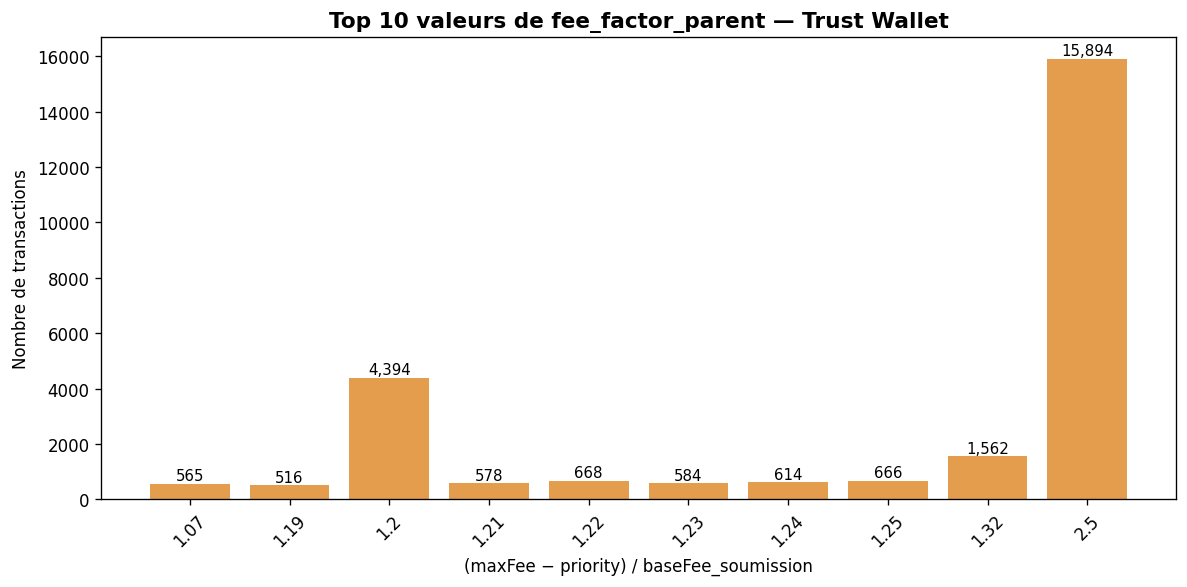


Top 10 valeurs de fee_factor_parent (arrondi à 2dp) :
fee_factor_parent
2.50    15894
1.20     4394
1.32     1562
1.22      668
1.25      666
1.24      614
1.23      584
1.21      578
1.07      565
1.19      516


In [3]:
ff_parent = df['fee_factor_parent'].dropna()
ff_parent_zoom = ff_parent[(ff_parent > 0.5) & (ff_parent <= 4.0)]

top_ffp = ff_parent_zoom.round(2).value_counts().head(10).sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(top_ffp.index.astype(str), top_ffp.values, color='#E08C2C', alpha=0.85)
ax.set_title('Top 10 valeurs de fee_factor_parent — Trust Wallet', fontsize=13, fontweight='bold')
ax.set_xlabel('(maxFee − priority) / baseFee_soumission')
ax.set_ylabel('Nombre de transactions')
ax.tick_params(axis='x', rotation=45)
for bar, val in zip(bars, top_ffp.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{val:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\nTop 10 valeurs de fee_factor_parent (arrondi à 2dp) :")
print(ff_parent_zoom.round(2).value_counts().head(10).to_string())

## 3. Top 15 — Gas limit factor (`gasLimit / estimatedGas`)

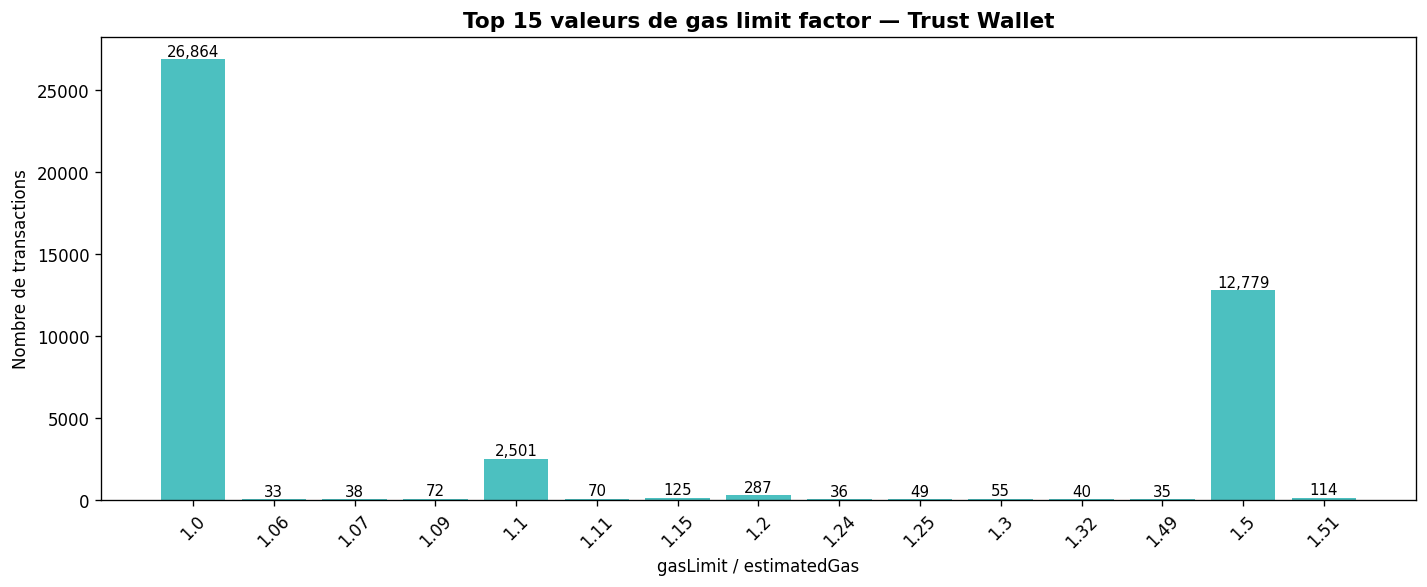


Top 15 valeurs de gas limit factor (arrondi à 2dp) :
gas_limit_factor
1.00    26864
1.50    12779
1.10     2501
1.20      287
1.15      125
1.51      114
1.09       72
1.11       70
1.30       55
1.25       49
1.32       40
1.07       38
1.24       36
1.49       35
1.06       33


In [4]:
glf = df['gas_limit_factor'].dropna()
glf_zoom = glf[(glf > 0.5) & (glf <= 5.0)]

top_glf = glf_zoom.round(2).value_counts().head(15).sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(top_glf.index.astype(str), top_glf.values, color='#2CB5B5', alpha=0.85)
ax.set_title('Top 15 valeurs de gas limit factor — Trust Wallet', fontsize=13, fontweight='bold')
ax.set_xlabel('gasLimit / estimatedGas')
ax.set_ylabel('Nombre de transactions')
ax.tick_params(axis='x', rotation=45)
for bar, val in zip(bars, top_glf.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{val:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\nTop 15 valeurs de gas limit factor (arrondi à 2dp) :")
print(glf_zoom.round(2).value_counts().head(15).to_string())